# Exploratory Data Analysis (EDA) Pipeline
**Purpose:** This cell imports all necessary system libraries, data visualization tools, and our custom OOP-based data loader to prepare the environment for text analysis.

In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from loguru import logger

# Ensure the root directory is accessible to import our custom utils package
sys.path.append('..')
from utils.data_loader import HuggingFaceCorpusLoader

### EDA Class Definition
**Purpose:** This cell defines the `TextExploratoryAnalyzer` class. Following strict OOP principles, this class encapsulates all logic required to inspect the dataset for missing values, calculate token lengths, and visualize class imbalances across our multi-language corpora.

In [2]:
class TextExploratoryAnalyzer:
    """
    Encapsulates logic for performing text-based Exploratory Data Analysis.
    """
    
    def __init__(self, dataframe: pd.DataFrame) -> None:
        """
        Initializes the analyzer with the target dataset.
        
        Args:
            dataframe (pd.DataFrame): The raw text dataset.
        """
        try:
            self.dataframe = dataframe.copy()
            logger.info("Initialized TextExploratoryAnalyzer.")
        except Exception as e:
            logger.error(f"Failed to initialize TextExploratoryAnalyzer: {e}")
            raise
            
    def analyze_missing_values(self, text_col: str) -> None:
        """
        Performs deep text anomaly detection to find NaNs, whitespace-only strings,
        and semantically meaningless micro-documents.
        
        Args:
            text_col (str): The column containing the raw text.
        """
        try:
            # 1. Check for standard database NaNs
            standard_nans = self.dataframe[text_col].isnull().sum()
            
            # 2. Check for "Ghost" strings (only spaces, tabs, or newlines)
            # We fillna("") first so string methods don't crash on actual NaNs
            whitespace_only = self.dataframe[text_col].fillna("").str.strip().eq("").sum() - standard_nans
            
            # 3. Check for micro-documents (less than 3 words)
            # These lack enough context for self-attention models to work properly
            word_counts = self.dataframe[text_col].fillna("").apply(lambda x: len(str(x).split()))
            micro_docs = (word_counts < 3).sum() - whitespace_only - standard_nans

            logger.info("Deep text anomaly detection completed.")
            print("\n--- True NLP Missing Values ---")
            print(f"Standard NaNs/Nulls:          {standard_nans}")
            print(f"Whitespace-Only 'Ghosts':     {whitespace_only}")
            print(f"Micro-Docs (< 3 words):       {micro_docs}")
            print("-------------------------------\n")
            
        except KeyError as ke:
            logger.error(f"Text column '{text_col}' not found: {ke}")
            raise
        except Exception as e:
            logger.error(f"Error computing deep missing values: {e}")
            raise
            
    def analyze_document_length_skewness(self, text_col: str) -> None:
        """
        Calculates the length of documents to identify extreme skewness in the vector space.
        
        Args:
            text_col (str): The column containing the raw text.
        """
        try:
            self.dataframe['doc_length'] = self.dataframe[text_col].apply(lambda x: len(str(x).split()))
            
            plt.figure(figsize=(10, 6))
            sns.histplot(self.dataframe['doc_length'], bins=50, kde=True, color='teal')
            plt.title("Document Length Distribution (Word Count)")
            plt.xlabel("Number of Words")
            plt.ylabel("Frequency")
            plt.show()
            
            logger.info(f"Median document length: {self.dataframe['doc_length'].median()} words")
        except KeyError as ke:
            logger.error(f"Text column '{text_col}' not found: {ke}")
            raise
        except Exception as e:
            logger.error(f"Error computing document length: {e}")
            raise
            
    def plot_class_distribution(self, target_col: str) -> None:
        """
        Visualizes the class distribution to check for extreme class imbalances.
        
        Args:
            target_col (str): The column containing the category labels.
        """
        try:
            plt.figure(figsize=(12, 6)) # Made it slightly wider
            # Added hue=target_col and legend=False to fix the Seaborn warning
            sns.countplot(data=self.dataframe, x=target_col, hue=target_col, palette="viridis", legend=False)
            plt.title("Document Category Distribution")
            plt.ylabel("Number of Documents")
            plt.xlabel("Category")
            
            # Rotate x-axis labels by 45 degrees so the 20 Newsgroups categories don't overlap
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout() # Ensures everything fits in the output box
            
            plt.show()
            logger.info("Class distribution plot generated successfully.")
        except KeyError as ke:
            logger.error(f"Target column '{target_col}' not found in dataframe: {ke}")
            raise
        except Exception as e:
            logger.error(f"Error plotting class distribution: {e}")
            raise

### Execution Pipeline
**Purpose:** This cell executes the data loading and EDA process. It instantiates the `HuggingFaceCorpusLoader` to pull the raw text data, passes it into the `TextExploratoryAnalyzer`, and triggers the analytical methods to output our insights.

2026-06-22 19:27:07.569 | INFO     | __main__:<module>:3 - Starting Data Loading process...
2026-06-22 19:27:07.569 | INFO     | utils.data_loader:__init__:42 - Initialized HuggingFaceCorpusLoader for SetFit/20_newsgroups
2026-06-22 19:27:07.569 | INFO     | utils.data_loader:load_data:55 - Downloading SetFit/20_newsgroups split: train
Repo card metadata block was not found. Setting CardData to empty.
2026-06-22 19:27:09.500 | INFO     | utils.data_loader:load_data:64 - Successfully loaded 11314 English documents.
2026-06-22 19:27:09.501 | INFO     | __main__:__init__:15 - Initialized TextExploratoryAnalyzer.
2026-06-22 19:27:09.579 | INFO     | __main__:analyze_missing_values:41 - Deep text anomaly detection completed.



--- True NLP Missing Values ---
Standard NaNs/Nulls:          0
Whitespace-Only 'Ghosts':     300
Micro-Docs (< 3 words):       55
-------------------------------



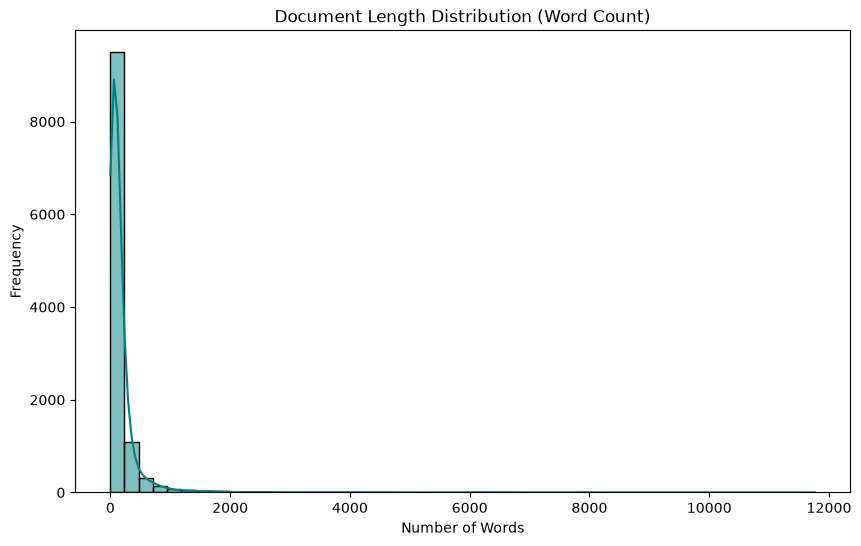

2026-06-22 19:27:09.761 | INFO     | __main__:analyze_document_length_skewness:72 - Median document length: 83.0 words


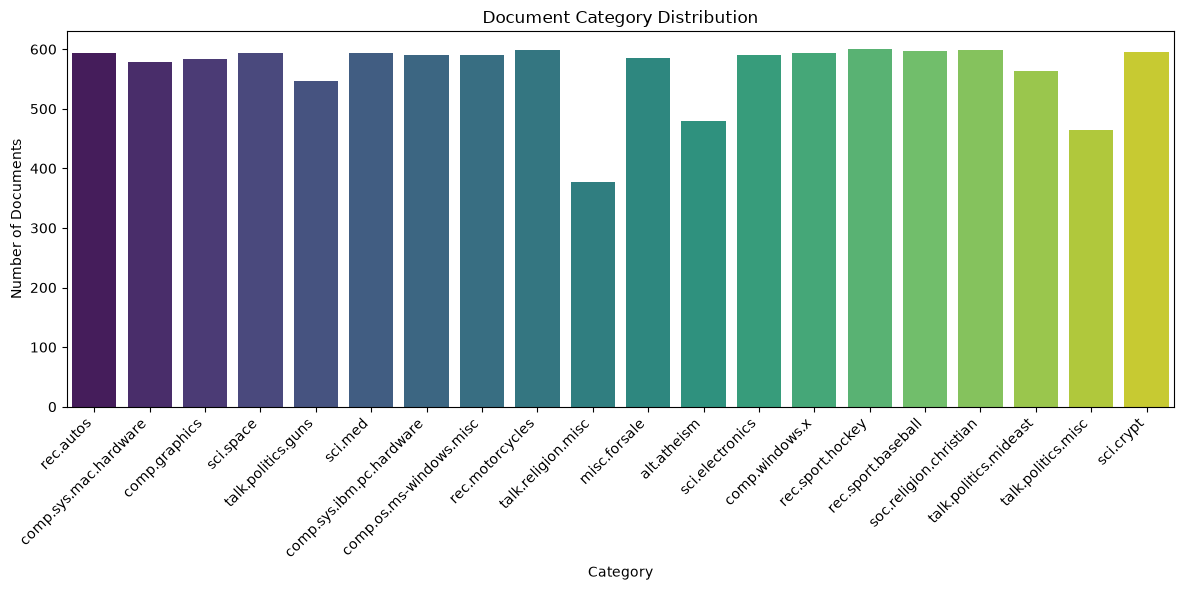

2026-06-22 19:27:09.916 | INFO     | __main__:plot_class_distribution:100 - Class distribution plot generated successfully.


In [3]:
# Execution block wrapped in a try/except for pipeline safety
try:
    logger.info("Starting Data Loading process...")
    
    # 1. Switch to the recommended 20 Newsgroups Dataset
    loader = HuggingFaceCorpusLoader(
        dataset_name="SetFit/20_newsgroups", 
        split="train" 
    )
    raw_df = loader.load_data()
    
    # 2. Initialize OOP Analyzer
    analyzer = TextExploratoryAnalyzer(raw_df)
    
    # 3. Perform EDA on the specific columns used by the 20 Newsgroups dataset
    # 'text' holds the documents, 'label_text' holds the 20 category names
    analyzer.analyze_missing_values(text_col='text')
    analyzer.analyze_document_length_skewness(text_col='text')
    analyzer.plot_class_distribution(target_col='label_text')
    
except Exception as main_err:
    logger.error(f"EDA Pipeline execution failed: {main_err}")

## Phase 2: Classification Engine Training
**Purpose:** This phase establishes a traditional machine learning baseline (TF-IDF + Logistic Regression) and then fine-tunes a deep learning architecture (DistilBERT) to compare their F1-Macro, AUC, and Accuracy metrics.

**Important Note:** We must set the environment variable to force legacy Keras compatibility before importing our models.

In [4]:
# CRITICAL: Force Legacy Keras BEFORE importing the classification models
%env TF_USE_LEGACY_KERAS=1

import sys
import pandas as pd
from sklearn.model_selection import train_test_split
from loguru import logger

sys.path.append('..')
from models.text_classifier import BaselineClassifier, DistilBertClassifier

env: TF_USE_LEGACY_KERAS=1


### Data Preparation, Cleaning & Splitting
**Purpose:** We apply our multi-language preprocessing pipeline to detect the language, sanitize the text (removing HTML/artifacts), and drop the empty "ghost" documents. Then, we apply a stratified split to prepare the features for training.

In [5]:
import sys
from tqdm.auto import tqdm
from utils.text_cleaning import LanguageSpecificSanitizer, CleaningObservabilityDecorator
from utils.language_detector import NgramLanguageDetector
from loguru import logger

# 1. PREVENT JUPYTER CRASH: Reconfigure Loguru
logger.remove() # Remove the default noisy logger
# Only show INFO and above in the Notebook cell
logger.add(sys.stderr, level="INFO") 
# Save all the heavy DEBUG observability logs to a file quietly in the background
logger.add("cleaning_observability.log", level="DEBUG")

# Enable progress bars for pandas
tqdm.pandas()

try:
    logger.info("Initializing Preprocessing Pipeline...")
    detector = NgramLanguageDetector()
    
    # 2. MEMORY OPTIMIZATION: Instantiate the decorators ONCE, not 11,000 times
    sanitizers = {
        "en": CleaningObservabilityDecorator(LanguageSpecificSanitizer("en")),
        "sv": CleaningObservabilityDecorator(LanguageSpecificSanitizer("sv")),
        "fi": CleaningObservabilityDecorator(LanguageSpecificSanitizer("fi"))
    }
    
    def preprocess_document(text):
        """Helper to detect language, clean, and handle NLP anomalies."""
        if not text or not str(text).strip():
            return None 
            
        try:
            lang = detector.detect_language(text)
            # Fetch the pre-instantiated sanitizer from the dictionary (fallback to English)
            sanitizer = sanitizers.get(lang, sanitizers["en"])
            return sanitizer.clean(text)
        except Exception:
            return None

    logger.info("Applying cleaning pipeline to the dataset (this will take 1-2 minutes)...")
    raw_df['clean_text'] = raw_df['text'].progress_apply(preprocess_document)
    
    # Drop the "ghost" and "micro" documents
    clean_df = raw_df.dropna(subset=['clean_text']).copy()
    logger.info(f"Dropped {len(raw_df) - len(clean_df)} invalid NLP documents.")
    
    X_clean = clean_df['clean_text'].tolist()
    y_clean = clean_df['label'].tolist()
    
    # Stratified Split: 80% Training, 20% Validation
    X_train, X_val, y_train, y_val = train_test_split(
        X_clean, y_clean, 
        test_size=0.2, 
        random_state=42, 
        stratify=y_clean
    )
    
    logger.info(f"Training samples: {len(X_train)} | Validation samples: {len(X_val)}")
except Exception as e:
    logger.error(f"Data preparation failed: {e}")

2026-06-22 19:27:14.456 | INFO     | __main__:<module>:18 - Initializing Preprocessing Pipeline...
2026-06-22 19:27:14.457 | INFO     | utils.language_detector:__init__:45 - Initialized NgramLanguageDetector. Supported partitions: ['en', 'sv', 'fi']
2026-06-22 19:27:14.457 | INFO     | __main__:<module>:41 - Applying cleaning pipeline to the dataset (this will take 1-2 minutes)...


  0%|          | 0/11314 [00:00<?, ?it/s]

2026-06-22 19:27:14.737 | ERROR    | utils.language_detector:detect_language:78 - N-gram detection failed on text '--
': No features in text.
2026-06-22 19:27:14.808 | WARNING  | utils.language_detector:detect_language:71 - Detected unsupported language 'de'. Defaulting to 'en'.
2026-06-22 19:27:15.034 | WARNING  | utils.language_detector:detect_language:71 - Detected unsupported language 'fr'. Defaulting to 'en'.
2026-06-22 19:27:15.053 | WARNING  | utils.language_detector:detect_language:71 - Detected unsupported language 'ro'. Defaulting to 'en'.
2026-06-22 19:27:15.241 | WARNING  | utils.language_detector:detect_language:71 - Detected unsupported language 'af'. Defaulting to 'en'.
2026-06-22 19:27:15.325 | WARNING  | utils.language_detector:detect_language:71 - Detected unsupported language 'sl'. Defaulting to 'en'.
2026-06-22 19:27:15.377 | ERROR    | utils.language_detector:detect_language:78 - N-gram detection failed on text '
		......@compuserve.com': No features in text.
2026-

### Step 1: The Baseline Model
**Purpose:** Train a Bag-of-Words Logistic Regression model. This gives us our "floor" metrics that the Deep Learning model must outperform by at least 5%.

In [6]:
try:
    logger.info("--- Starting Baseline Training ---")
    baseline = BaselineClassifier(max_features=10000)
    baseline.train(X_train, y_train, X_val, y_val)
    
    logger.info("Baseline Evaluation completed.")
except Exception as e:
    logger.error(f"Baseline execution failed: {e}")

2026-06-22 19:27:39.629 | INFO     | __main__:<module>:2 - --- Starting Baseline Training ---
2026-06-22 19:27:39.900 | INFO     | utils.tokenization:__init__:44 - Initialized SpacyTokenizer with model 'en_core_web_sm'.
2026-06-22 19:27:40.104 | INFO     | utils.tokenization:__init__:44 - Initialized SpacyTokenizer with model 'sv_core_news_sm'.
2026-06-22 19:27:41.204 | INFO     | utils.tokenization:__init__:86 - Initialized FinnishSubwordTokenizer with 'distilbert-base-multilingual-cased'.
2026-06-22 19:27:41.205 | INFO     | models.text_classifier:__init__:89 - Initialized BaselineClassifier with custom TokenizerFactory.
2026-06-22 19:27:41.205 | INFO     | models.text_classifier:train:93 - Training Baseline Model...
2026-06-22 19:30:22.343 | INFO     | models.text_classifier:train:96 - Baseline training complete.
2026-06-22 19:30:22.344 | INFO     | models.text_classifier:train:99 - Evaluating Baseline on Validation Set:
2026-06-22 19:30:56.708 | INFO     | models.text_classifier:ev

### Step 2: Fine-Tuning DistilBERT
**Purpose:** Fine-tune the pre-trained DistilBERT transformer over 5 epochs. Callbacks will automatically save the `text_classifier_best.weights.h5`, `config.json`, and `training_history.csv` to the `models/checkpoints/` directory.

In [ ]:
try:
    logger.info("--- Starting DistilBERT Fine-Tuning ---")
    # We have 20 unique categories in the 20 Newsgroups dataset
    dl_model = DistilBertClassifier(num_classes=20)
    
    # Train for 5 epochs (as required by the issue specs)
    dl_model.train(X_train, y_train, X_val, y_val, epochs=5)
    
    logger.info("Evaluating DistilBERT on Validation Set:")
    dl_metrics = dl_model.evaluate(X_val, y_val)
    
except Exception as e:
    logger.error(f"DistilBERT execution failed: {e}")

2026-06-22 19:30:56.712 | INFO     | __main__:<module>:2 - --- Starting DistilBERT Fine-Tuning ---
2026-06-22 19:30:56.713 | INFO     | models.text_classifier:__init__:129 - Loading tokenizer and pre-trained weights for distilbert-base-multilingual-cased...
TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at distilbert-base-multilingual-cased were not used when initializing TFDistilBertForSequenceClassification: ['activation_13', 'vocab_layer_norm', 'vocab_projector', 'vocab_transform']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the chec

Epoch 1/5
